# Flight Delay Analysis — EDA Charts
**CS 4365 Group 10 | Spring 2026**

This notebook produces all 7 EDA charts from `merged_flights.csv`.
Chart 8 (Feature Importance) is generated in the ML notebook after Random Forest trains.

| # | Chart | Type |
|---|---|---|
| 1 | Monthly Delay Rate | Bar chart |
| 2 | Hour-of-Day Ripple | Line chart |
| 3 | Airline Performance | Horizontal bar |
| 4 | Delay Cause by Month | Stacked bar |
| 5 | Worst Airports | Horizontal bar |
| 6 | Cancellation Rate by Airline | Grouped bar |
| 7 | Correlation Heatmap | Seaborn heatmap |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os

# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH   = 'merged_flights.csv'   # adjust if running from a different folder
OUTPUT_DIR  = 'charts'               # PNGs saved here
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Consistent style across all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load & prepare data ───────────────────────────────────────────────────────
print('Loading data...')
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'  {len(df):,} rows loaded')

# Parse date and extract time features
df['FL_DATE']  = pd.to_datetime(df['FL_DATE'], errors='coerce')
df['Month']    = df['FL_DATE'].dt.month
df['DayOfWeek']= df['FL_DATE'].dt.dayofweek
df['IsWeekend']= (df['DayOfWeek'] >= 5).astype(int)

# Extract DepHour from CRS_DEP_TIME string (format: "6:59:00")
df['DepHour'] = (
    df['CRS_DEP_TIME']
    .astype(str)
    .str.split(':')
    .str[0]
    .str.strip()
    .replace('nan', np.nan)
    .astype(float)
    .clip(0, 23)
    .astype('Int64')
)

# Extract carrier from FL_UNIQUE_NUM (e.g. "AA1" -> "AA")
df['Carrier'] = df['FL_UNIQUE_NUM'].str.extract(r'^([A-Z]{2})')

# Fill delay cause nulls with 0 (non-delayed flights have no cause)
delay_cause_cols = ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY',
                    'SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
df[delay_cause_cols] = df[delay_cause_cols].fillna(0)

# Separate non-cancelled flights for delay analysis
df_flights = df[df['CANCELLED'] == 0].copy()

print(f'  {len(df_flights):,} non-cancelled flights for delay analysis')
print(f'  {df["Carrier"].nunique()} carriers | {df["ORIGIN"].nunique()} origin airports')
print('Data ready.')

Loading data...
  6,419,315 rows loaded
  6,325,440 non-cancelled flights for delay analysis
  11 carriers | 350 origin airports
Data ready.


---
## Chart 1 — Monthly Delay Rate
**Question:** Which months have the highest proportion of delayed flights?

Expected pattern: summer (June–August) and winter (December–January) should spike.

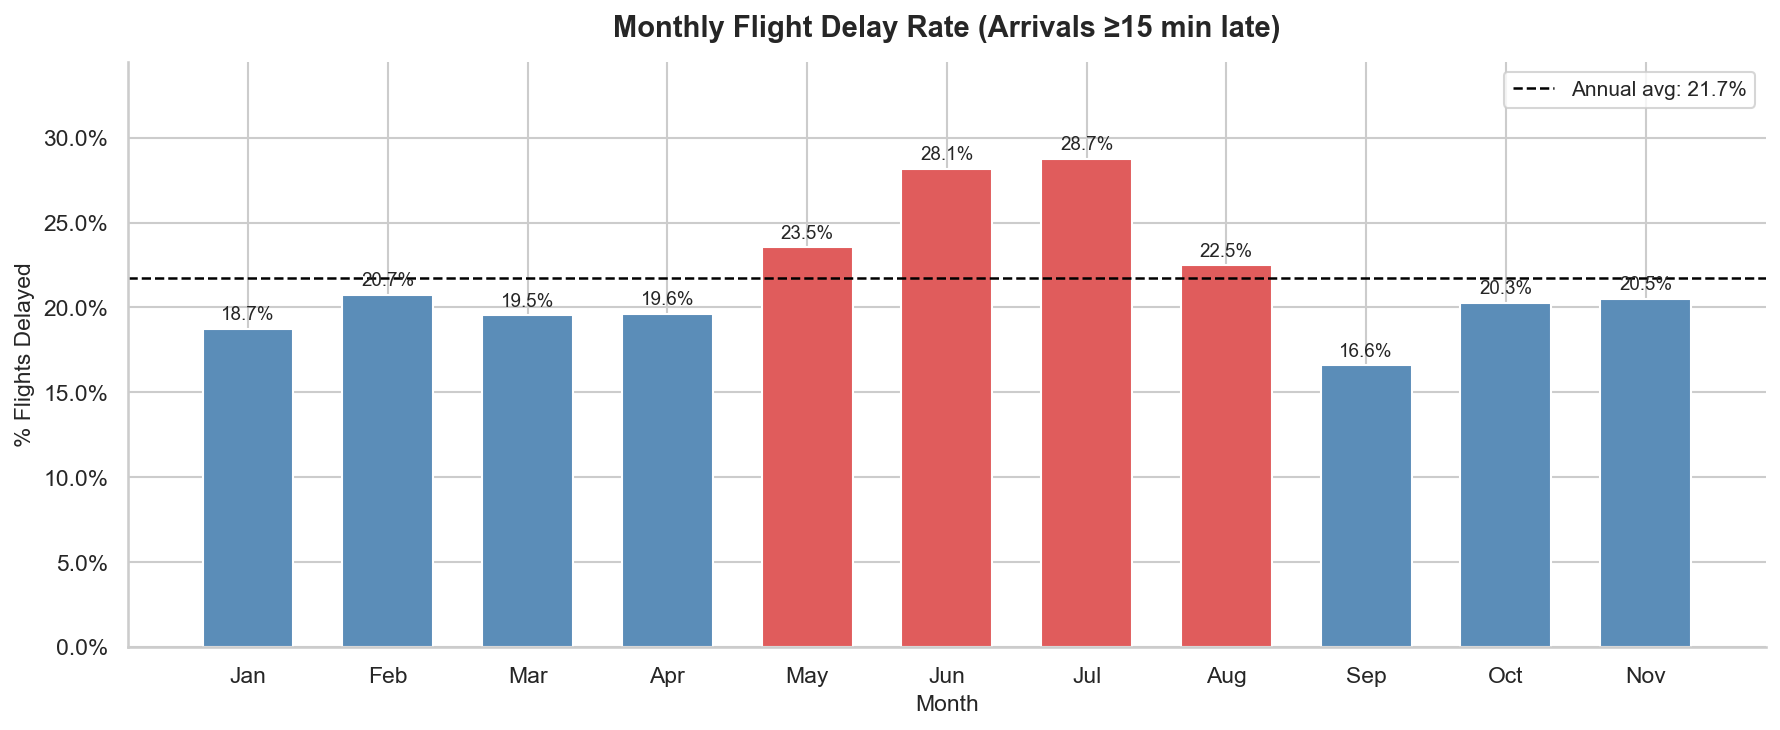

Chart 1 saved.


In [5]:
monthly = (
    df_flights.groupby('Month')['ARR_DEL15']
    .mean()
    .reset_index()
)
monthly.columns = ['Month', 'DelayRate']
monthly['DelayRate'] = monthly['DelayRate'] * 100
monthly['MonthLabel'] = monthly['Month'].apply(lambda m: MONTH_LABELS[m-1])

avg_rate = monthly['DelayRate'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#e05c5c' if r > avg_rate else '#5b8db8' for r in monthly['DelayRate']]
bars = ax.bar(monthly['MonthLabel'], monthly['DelayRate'], color=colors, width=0.65, edgecolor='white')

ax.axhline(avg_rate, color='black', linewidth=1.2, linestyle='--', label=f'Annual avg: {avg_rate:.1f}%')

# Label each bar
for bar, val in zip(bars, monthly['DelayRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Monthly Flight Delay Rate (Arrivals ≥15 min late)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('% Flights Delayed', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
ax.set_ylim(0, monthly['DelayRate'].max() * 1.2)
sns.despine()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart1_monthly_delay_rate.png')
plt.show()
print('Chart 1 saved.')

---
## Chart 2 — Hour-of-Day Ripple
**Question:** How does departure time affect delay probability throughout the day?

Expected: early morning flights are cleanest; delays compound through the day and peak around 6–9pm.

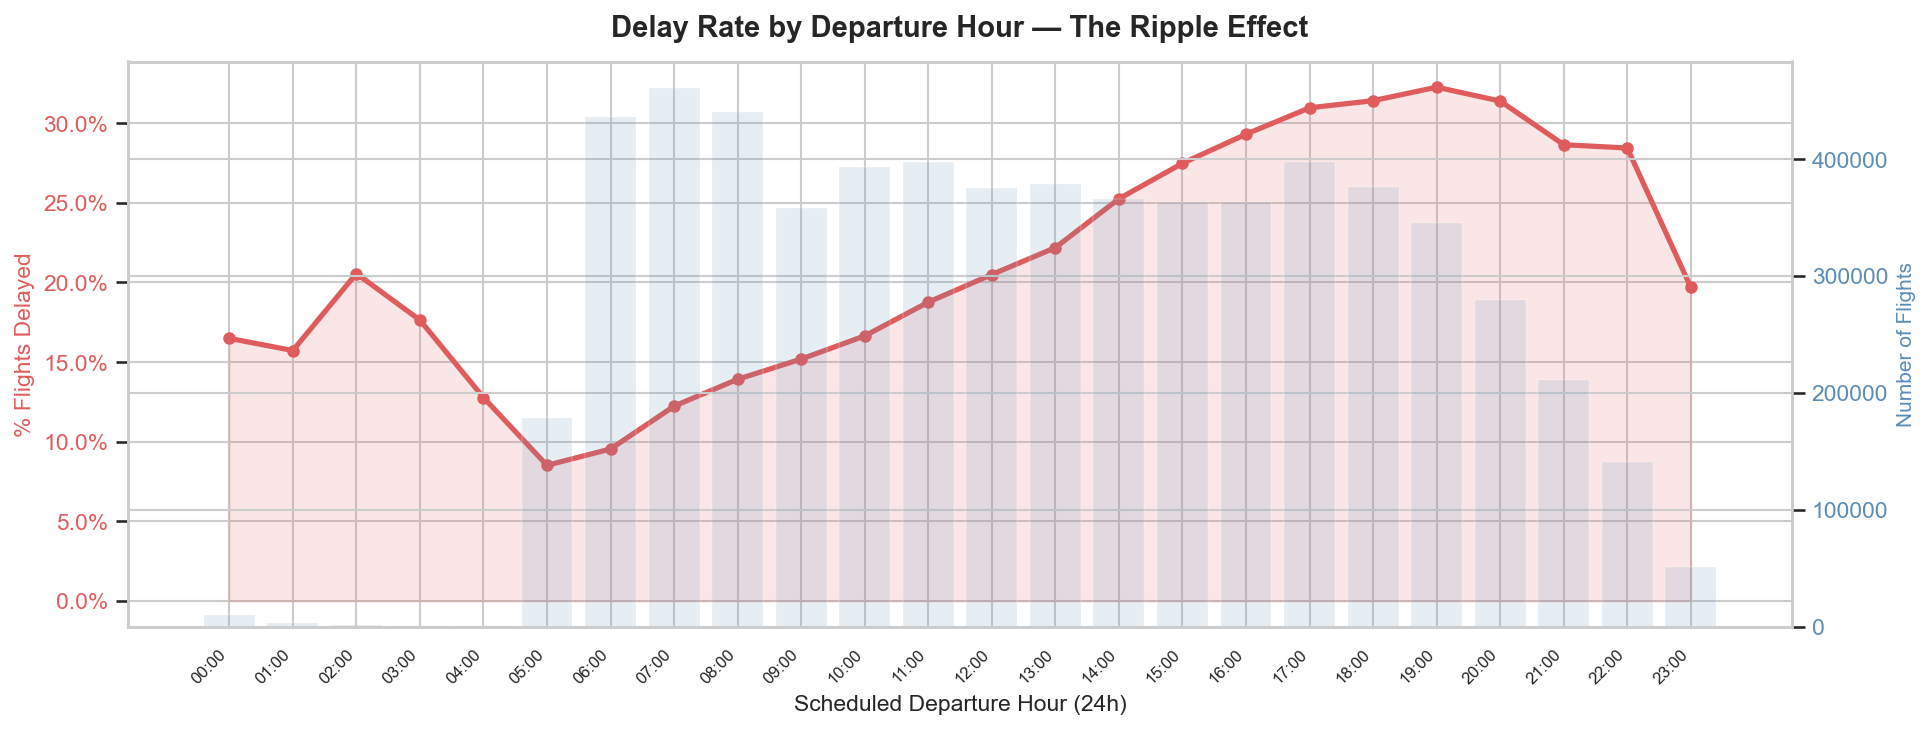

Chart 2 saved.


In [6]:
hourly = (
    df_flights.groupby('DepHour')['ARR_DEL15']
    .agg(['mean', 'count'])
    .reset_index()
)
hourly.columns = ['DepHour', 'DelayRate', 'FlightCount']
hourly['DelayRate'] *= 100
hourly = hourly[hourly['FlightCount'] > 100]  # remove hours with very few flights

fig, ax1 = plt.subplots(figsize=(13, 5))

# Shaded area under line
ax1.fill_between(hourly['DepHour'], hourly['DelayRate'], alpha=0.15, color='#e05c5c')
ax1.plot(hourly['DepHour'], hourly['DelayRate'], color='#e05c5c', linewidth=2.5, marker='o', markersize=5)

# Flight volume bars on secondary axis
ax2 = ax1.twinx()
ax2.bar(hourly['DepHour'], hourly['FlightCount'], alpha=0.15, color='#5b8db8', width=0.8)
ax2.set_ylabel('Number of Flights', fontsize=10, color='#5b8db8')
ax2.tick_params(axis='y', labelcolor='#5b8db8')

ax1.set_title('Delay Rate by Departure Hour — The Ripple Effect', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Scheduled Departure Hour (24h)', fontsize=11)
ax1.set_ylabel('% Flights Delayed', fontsize=11, color='#e05c5c')
ax1.tick_params(axis='y', labelcolor='#e05c5c')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_xticks(range(0, 24))
ax1.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart2_hourly_delay_ripple.png')
plt.show()
print('Chart 2 saved.')

---
## Chart 3 — Airline Performance
**Question:** Which airlines are above vs below the average delay rate?

Bars above average shown in red, below in green.

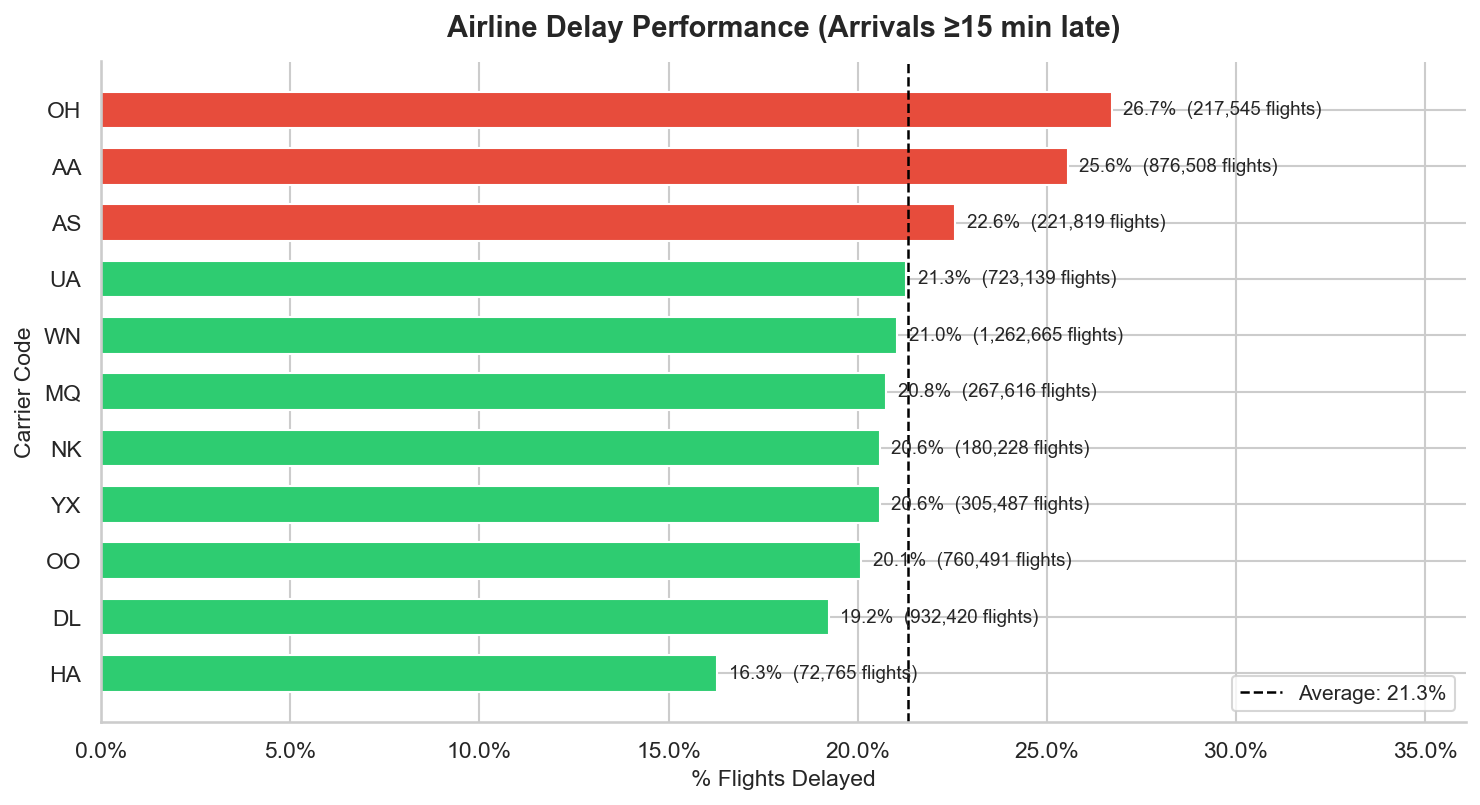

Chart 3 saved.


In [7]:
airline_perf = (
    df_flights.groupby('Carrier')
    .agg(DelayRate=('ARR_DEL15', 'mean'), FlightCount=('ARR_DEL15', 'count'))
    .reset_index()
)
airline_perf['DelayRate'] *= 100
airline_perf = airline_perf[airline_perf['FlightCount'] > 500]  # remove tiny carriers
airline_perf = airline_perf.sort_values('DelayRate', ascending=True)

avg = airline_perf['DelayRate'].mean()
colors = ['#2ecc71' if r <= avg else '#e74c3c' for r in airline_perf['DelayRate']]

fig, ax = plt.subplots(figsize=(10, max(5, len(airline_perf) * 0.5)))

bars = ax.barh(airline_perf['Carrier'], airline_perf['DelayRate'],
               color=colors, edgecolor='white', height=0.65)

ax.axvline(avg, color='black', linewidth=1.2, linestyle='--', label=f'Average: {avg:.1f}%')

for bar, val, cnt in zip(bars, airline_perf['DelayRate'], airline_perf['FlightCount']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  ({cnt:,} flights)', va='center', fontsize=9)

ax.set_title('Airline Delay Performance (Arrivals ≥15 min late)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('% Flights Delayed', fontsize=11)
ax.set_ylabel('Carrier Code', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, airline_perf['DelayRate'].max() * 1.35)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart3_airline_performance.png')
plt.show()
print('Chart 3 saved.')

---
## Chart 4 — Delay Cause by Month (Stacked Bar)
**Question:** What TYPE of delay dominates each month?

This is your most analytically important chart — it shows the mechanism behind delays, not just when they happen.

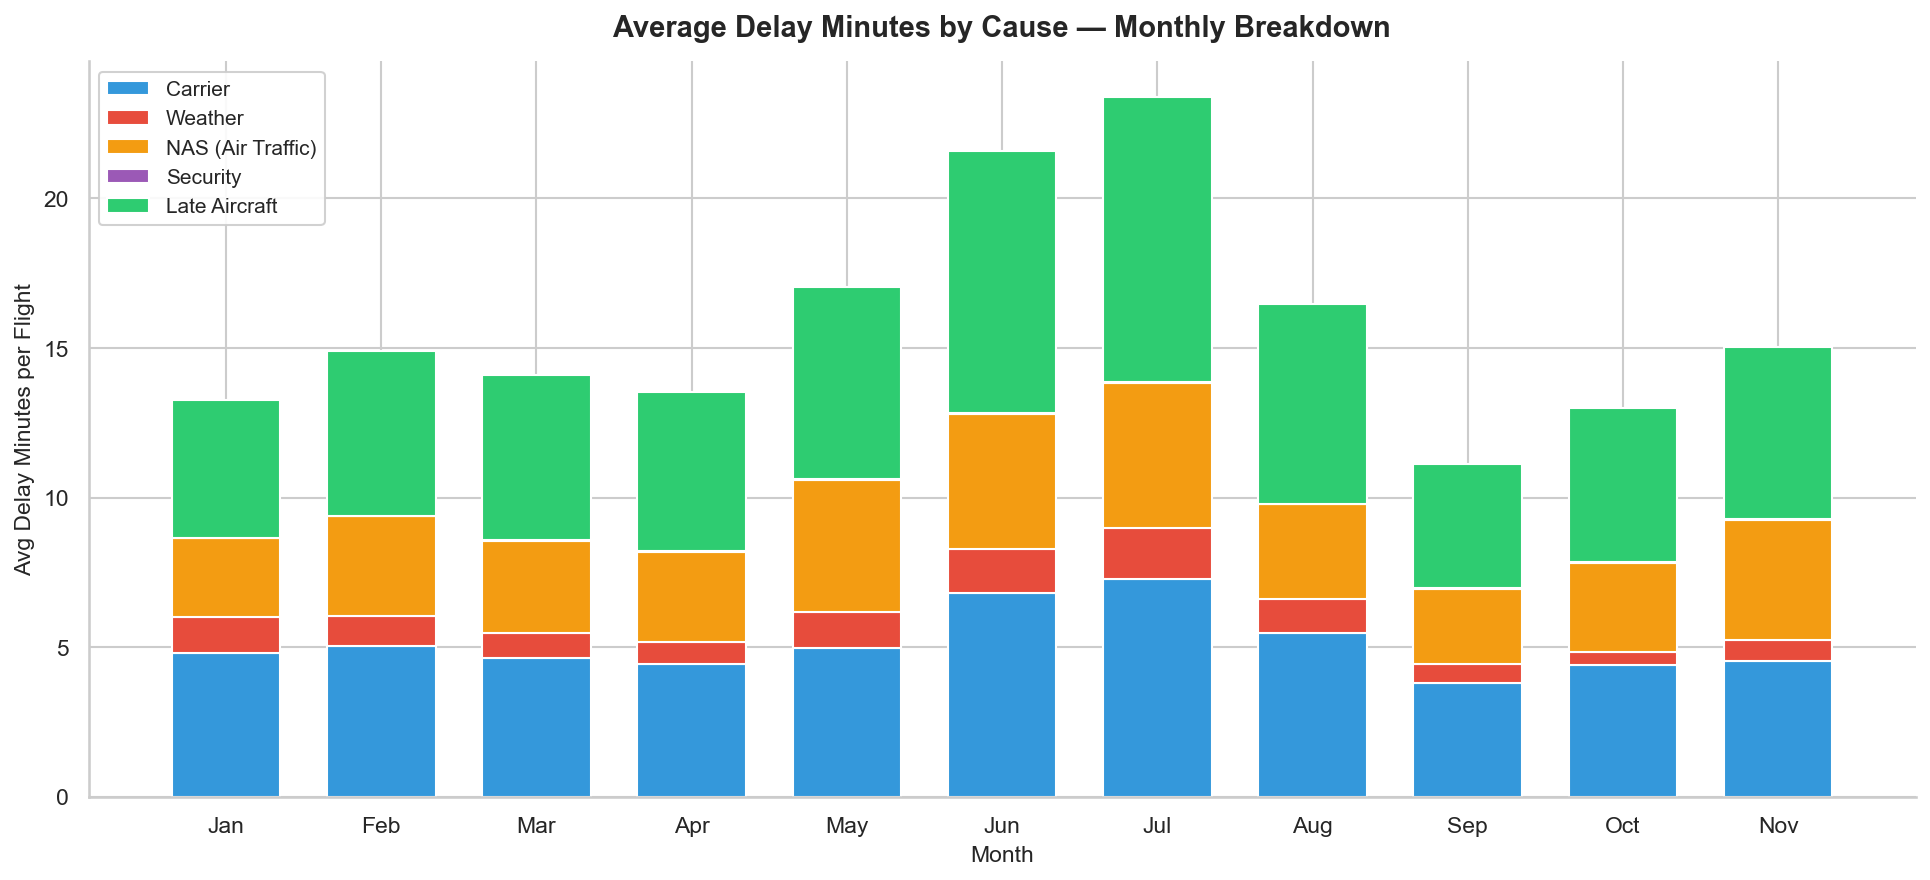

Chart 4 saved.


In [8]:
cause_monthly = (
    df_flights.groupby('Month')[delay_cause_cols]
    .mean()
    .reset_index()
)
cause_monthly['MonthLabel'] = cause_monthly['Month'].apply(lambda m: MONTH_LABELS[m-1])

cause_labels = {
    'CARRIER_DELAY':      'Carrier',
    'WEATHER_DELAY':      'Weather',
    'NAS_DELAY':          'NAS (Air Traffic)',
    'SECURITY_DELAY':     'Security',
    'LATE_AIRCRAFT_DELAY':'Late Aircraft',
}
cause_colors = ['#3498db','#e74c3c','#f39c12','#9b59b6','#2ecc71']

fig, ax = plt.subplots(figsize=(13, 6))

bottom = np.zeros(len(cause_monthly))
for (col, label), color in zip(cause_labels.items(), cause_colors):
    vals = cause_monthly[col].values
    ax.bar(cause_monthly['MonthLabel'], vals, bottom=bottom,
           label=label, color=color, edgecolor='white', width=0.7)
    bottom += vals

ax.set_title('Average Delay Minutes by Cause — Monthly Breakdown', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Avg Delay Minutes per Flight', fontsize=11)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
sns.despine()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart4_delay_cause_by_month.png')
plt.show()
print('Chart 4 saved.')

---
## Chart 5 — Worst Airports
**Question:** Which origin airports have the worst average arrival delays?

Shows structural hub bottlenecks — justifies Origin as an ML feature.

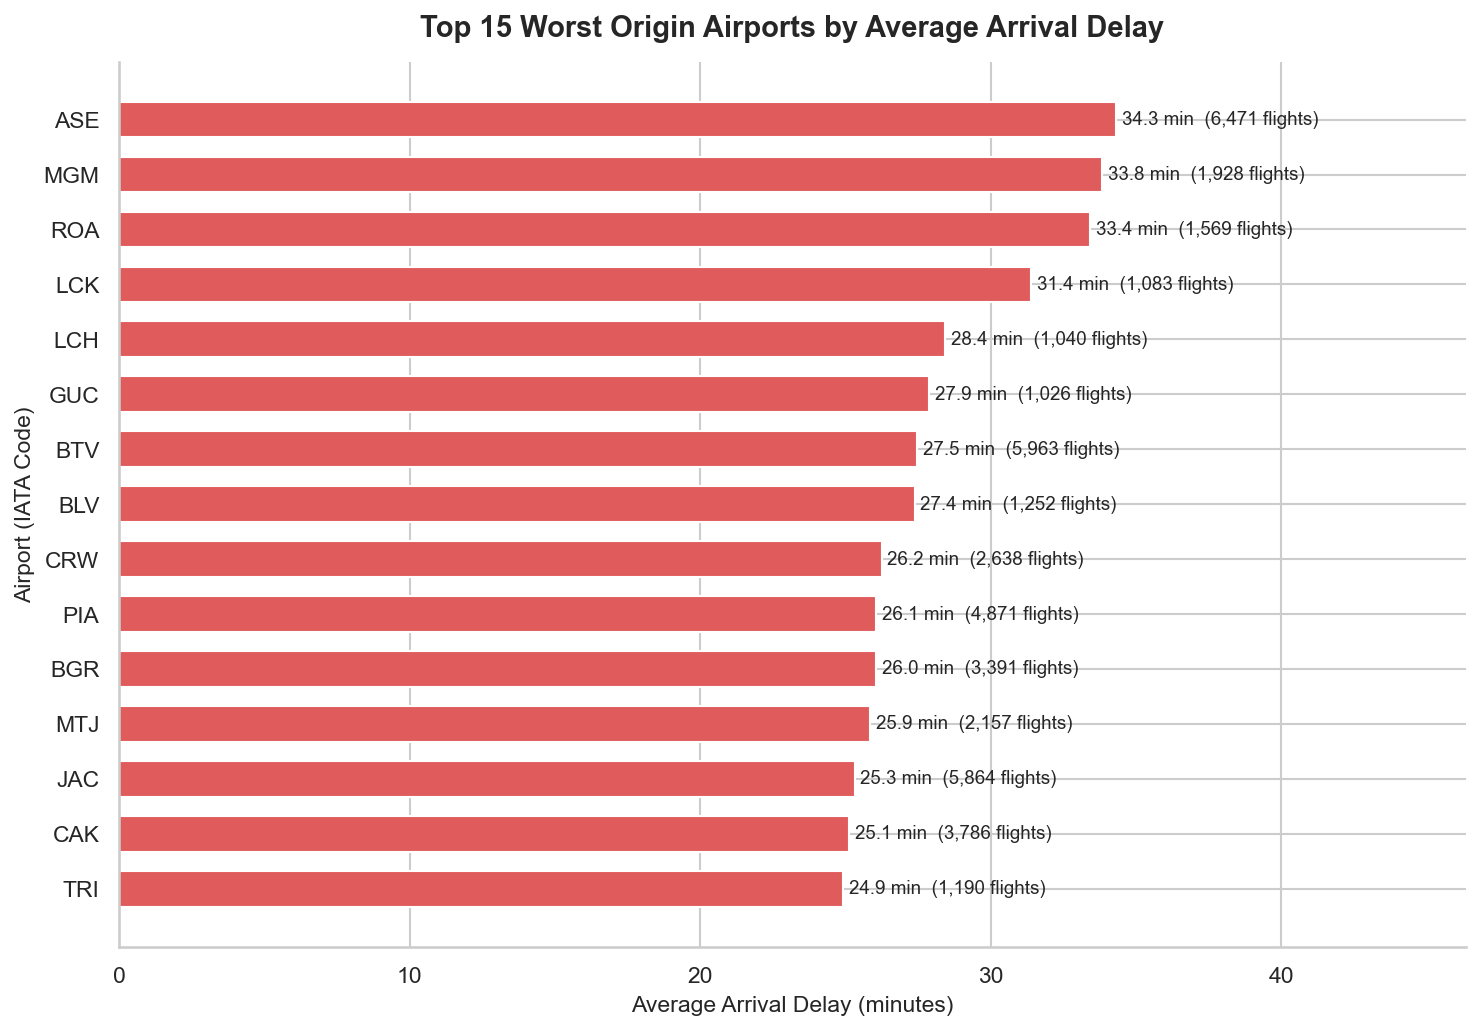

Chart 5 saved.


In [9]:
airport_delays = (
    df_flights.groupby('ORIGIN')
    .agg(AvgDelay=('ARR_DELAY_NEW', 'mean'), FlightCount=('ARR_DELAY_NEW', 'count'))
    .reset_index()
)
# Only airports with enough flights to be meaningful
airport_delays = airport_delays[airport_delays['FlightCount'] >= 1000]
top15 = airport_delays.nlargest(15, 'AvgDelay').sort_values('AvgDelay', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top15['ORIGIN'], top15['AvgDelay'],
               color='#e05c5c', edgecolor='white', height=0.65)

for bar, val, cnt in zip(bars, top15['AvgDelay'], top15['FlightCount']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} min  ({cnt:,} flights)', va='center', fontsize=9)

ax.set_title('Top 15 Worst Origin Airports by Average Arrival Delay', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average Arrival Delay (minutes)', fontsize=11)
ax.set_ylabel('Airport (IATA Code)', fontsize=11)
ax.set_xlim(0, top15['AvgDelay'].max() * 1.35)
sns.despine()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart5_worst_airports.png')
plt.show()
print('Chart 5 saved.')

---
## Chart 6 — Cancellation Rate by Airline
**Question:** Which airlines cancel the most flights?

Note: Your dataset does not include CANCELLATION_CODE, so this shows overall cancellation rate per carrier.

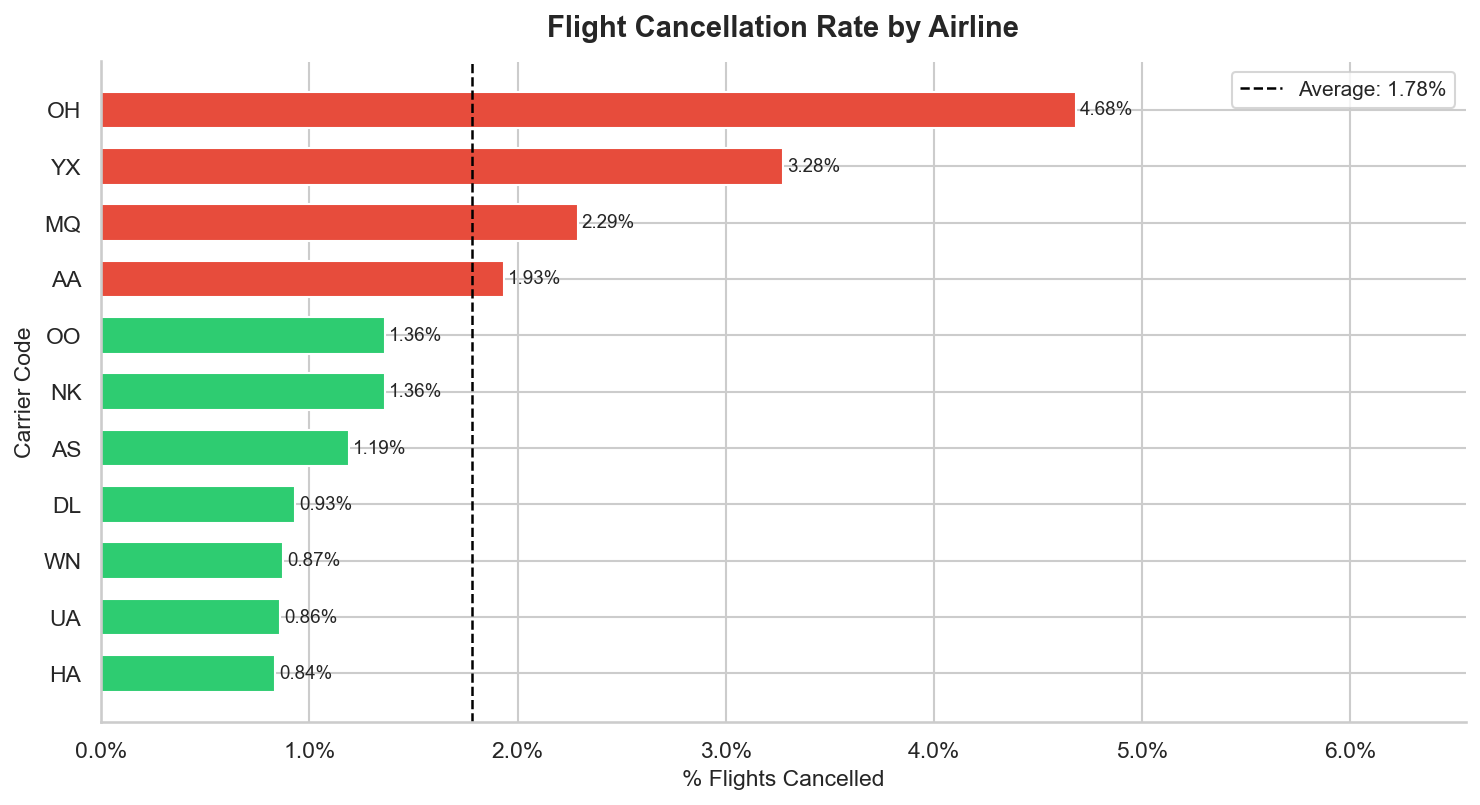

Chart 6 saved.


In [10]:
cancel_by_airline = (
    df.groupby('Carrier')
    .agg(CancelRate=('CANCELLED', 'mean'), TotalFlights=('CANCELLED', 'count'))
    .reset_index()
)
cancel_by_airline['CancelRate'] *= 100
cancel_by_airline = cancel_by_airline[cancel_by_airline['TotalFlights'] > 500]
cancel_by_airline = cancel_by_airline.sort_values('CancelRate', ascending=True)

avg_cancel = cancel_by_airline['CancelRate'].mean()
colors = ['#2ecc71' if r <= avg_cancel else '#e74c3c' for r in cancel_by_airline['CancelRate']]

fig, ax = plt.subplots(figsize=(10, max(5, len(cancel_by_airline) * 0.5)))

bars = ax.barh(cancel_by_airline['Carrier'], cancel_by_airline['CancelRate'],
               color=colors, edgecolor='white', height=0.65)

ax.axvline(avg_cancel, color='black', linewidth=1.2, linestyle='--',
           label=f'Average: {avg_cancel:.2f}%')

for bar, val in zip(bars, cancel_by_airline['CancelRate']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)

ax.set_title('Flight Cancellation Rate by Airline', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('% Flights Cancelled', fontsize=11)
ax.set_ylabel('Carrier Code', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, cancel_by_airline['CancelRate'].max() * 1.4)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart6_cancellation_by_airline.png')
plt.show()
print('Chart 6 saved.')

---
## Chart 7 — Correlation Heatmap
**Question:** How do the delay cause variables relate to each other?

Expected: DEP_DELAY and ARR_DELAY will be tightly correlated. LATE_AIRCRAFT chains with others.

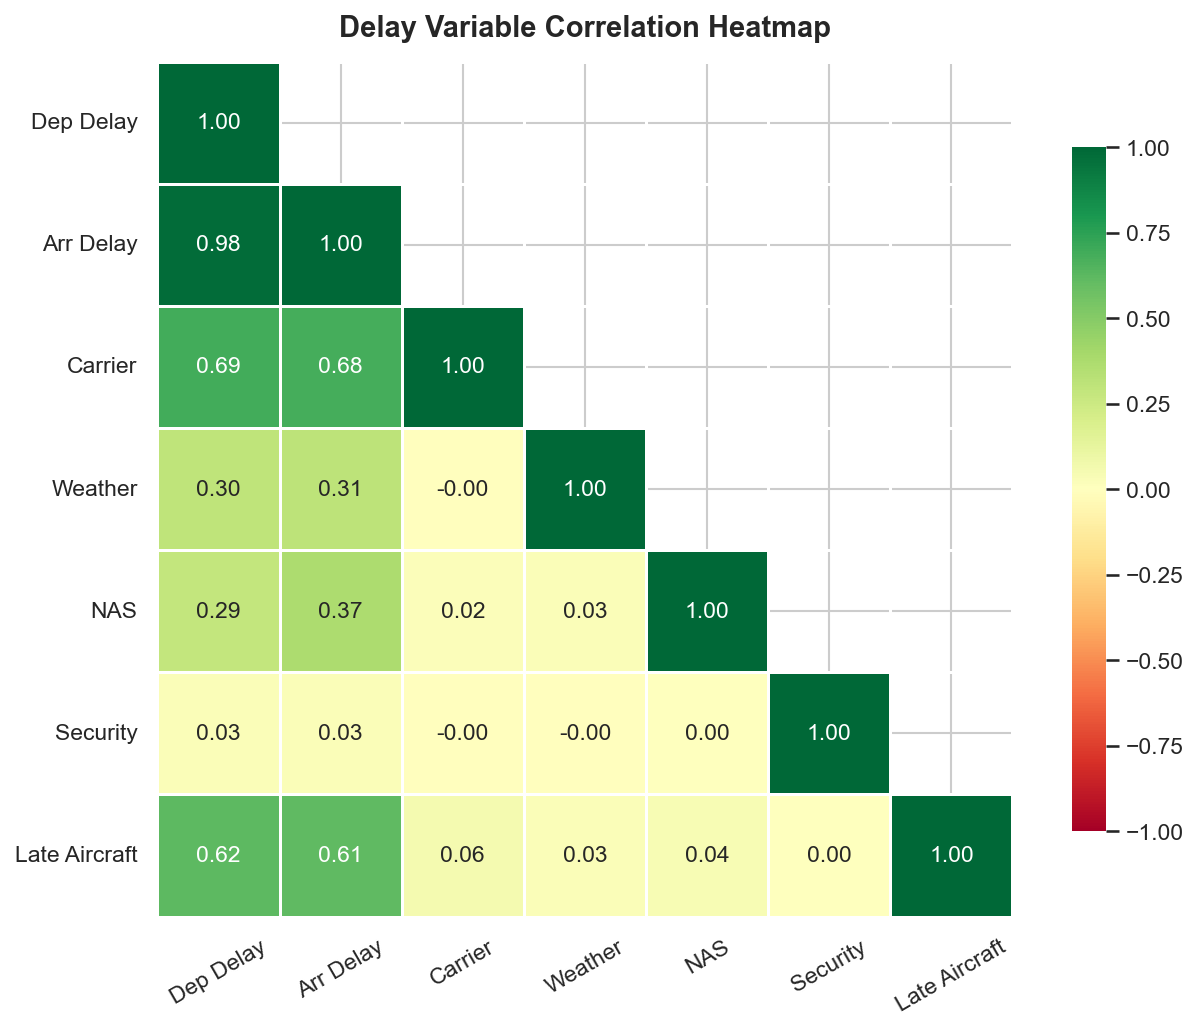

Chart 7 saved.


In [11]:
corr_cols = [
    'DEP_DELAY_NEW', 'ARR_DELAY_NEW',
    'CARRIER_DELAY', 'WEATHER_DELAY',
    'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

corr_labels = [
    'Dep Delay', 'Arr Delay',
    'Carrier', 'Weather',
    'NAS', 'Security', 'Late Aircraft'
]

corr_df = df_flights[corr_cols].copy()
corr_df.columns = corr_labels
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Delay Variable Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart7_correlation_heatmap.png')
plt.show()
print('Chart 7 saved.')

---
## Summary
All 7 charts saved to the `charts/` folder.

In [12]:
saved = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')]
print(f'{len(saved)} charts saved to ./{OUTPUT_DIR}/')
for f in sorted(saved):
    print(f'  {f}')

print('\nNext step: run ml_models.ipynb to train Logistic Regression + Random Forest')
print('Chart 8 (Feature Importance) will be generated there and added to this folder.')

7 charts saved to ./charts/
  chart1_monthly_delay_rate.png
  chart2_hourly_delay_ripple.png
  chart3_airline_performance.png
  chart4_delay_cause_by_month.png
  chart5_worst_airports.png
  chart6_cancellation_by_airline.png
  chart7_correlation_heatmap.png

Next step: run ml_models.ipynb to train Logistic Regression + Random Forest
Chart 8 (Feature Importance) will be generated there and added to this folder.
